#**Austo Motor Company**

##Problem Statement

###Context

Austo Motor Company is a leading car manufacturer specializing in SUV, Sedan, and Hatchback models. In its recent board meeting, concerns were raised by the members on the efficiency of the marketing campaign currently being used. The board decides to rope in an analytics professional to improve the existing campaign.

###Objective


They want to analyze the data to get a fair idea about the demand of customers which will help them in enhancing their customer experience. Suppose you are a Data Scientist at the company and the Data Science team has shared some of the key questions that need to be answered. Perform the data analysis to find answers to these questions that will help the company to improve the business.

### Data Description

* Age: The age of the individual in years.
* Gender: The gender of the individual, categorized as male or female.
* Profession: The occupation or profession of the individual.
* Marital_status: The marital status of the individual, such as married &, single
* Education: The educational qualification of the individual Graduate and Post Graduate
* No_of_Dependents: The number of dependents (e.g., children, elderly parents) that the individual supports financially.
* Personal_loan: A binary variable indicating whether the individual has taken a personal loan "Yes" or "No"
* House_loan: A binary variable indicating whether the individual has taken a housing loan "Yes" or "No"
* Partner_working: A binary variable indicating whether the individual's partner is employed "Yes" or "No"
* Salary: The individual's salary or income.
* Partner_salary: The salary or income of the individual's partner, if applicable.
* Total_salary: The total combined salary of the individual and their partner (if applicable).
* Price: The price of a product or service.
* Make: The type of automobile

## Data Overview

Importing Various libraries

In [1]:
#import all the libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [3]:
#import warnings to prevent unnecessery warnings
import warnings
warnings.filterwarnings('ignore')

Loading data

In [4]:
#load the data
df = pd.read_csv('/content/austo_automobile .csv')

Displaying first 5 rows of dataset

In [5]:
#displaying first 5 rows of dataset
df.head()

,Age,Gender,Profession,Marital_status,Education,No_of_Dependents,Personal_loan,House_loan,Partner_working,Salary,Partner_salary,Total_salary,Price,Make
0,53,Male,Business,Married,Post Graduate,4,No,No,Yes,99300,70700.0,170000,61000,SUV
1,53,Femal,Salaried,Married,Post Graduate,4,Yes,No,Yes,95500,70300.0,165800,61000,SUV
2,53,Female,Salaried,Married,Post Graduate,3,No,No,Yes,97300,60700.0,158000,57000,SUV
3,53,Female,Salaried,Married,Graduate,2,Yes,No,Yes,72500,70300.0,142800,61000,SUV
4,53,Male,Salaried,Married,Post Graduate,3,No,No,Yes,79700,60200.0,139900,57000,SUV




*   *Dataset contains information of customers who have reached out regarding purchase of car.*
*   *It contains details about the customers, their dependents, financial details and enquired models.*


Understanding shape of dataset

In [6]:
#shape of the dataset
df.shape

(1581, 14)



*  *There are 1581 rows and 14 columns in the dataset.*



Checking datatypes of columns

In [7]:
#checking the datatypes of columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1581 entries, 0 to 1580
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Age               1581 non-null   int64  
 1   Gender            1528 non-null   object 
 2   Profession        1581 non-null   object 
 3   Marital_status    1581 non-null   object 
 4   Education         1581 non-null   object 
 5   No_of_Dependents  1581 non-null   int64  
 6   Personal_loan     1581 non-null   object 
 7   House_loan        1581 non-null   object 
 8   Partner_working   1581 non-null   object 
 9   Salary            1581 non-null   int64  
 10  Partner_salary    1475 non-null   float64
 11  Total_salary      1581 non-null   int64  
 12  Price             1581 non-null   int64  
 13  Make              1581 non-null   object 
dtypes: float64(1), int64(5), object(8)
memory usage: 173.1+ KB




*   *There are 8 categorical columns and 6 numerical columns*



In [8]:
#finding missing values
df.isnull().sum()

,0
Age,0
Gender,53
Profession,0
Marital_status,0
Education,0
No_of_Dependents,0
Personal_loan,0
House_loan,0
Partner_working,0
Salary,0


Treating Missing Values

In [9]:
#treating missing values of Partner_salary
df['Partner_salary'].fillna(df['Total_salary'] - df['Salary'], inplace=True)

In [10]:
#treating missing values of Gender
df['Gender'].fillna('Unknown', inplace=True)

Checking for Irregularities

In [11]:
#checking any non-null values left
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1581 entries, 0 to 1580
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Age               1581 non-null   int64  
 1   Gender            1581 non-null   object 
 2   Profession        1581 non-null   object 
 3   Marital_status    1581 non-null   object 
 4   Education         1581 non-null   object 
 5   No_of_Dependents  1581 non-null   int64  
 6   Personal_loan     1581 non-null   object 
 7   House_loan        1581 non-null   object 
 8   Partner_working   1581 non-null   object 
 9   Salary            1581 non-null   int64  
 10  Partner_salary    1581 non-null   float64
 11  Total_salary      1581 non-null   int64  
 12  Price             1581 non-null   int64  
 13  Make              1581 non-null   object 
dtypes: float64(1), int64(5), object(8)
memory usage: 173.1+ KB


Getting Statistical summary of dataset

In [12]:
#checking statistical summary
df.describe()

,Age,No_of_Dependents,Salary,Partner_salary,Total_salary,Price
count,1581.000000,1581.000000,1581.000000,1581.000000,1581.000000,1581.000000
mean,31.922201,2.457938,60392.220114,19233.776091,79625.996205,35597.722960
std,8.425978,0.943483,14674.825044,19670.391171,25545.857768,13633.636545
min,22.000000,0.000000,30000.000000,0.000000,30000.000000,18000.000000
25%,25.000000,2.000000,51900.000000,0.000000,60500.000000,25000.000000
50%,29.000000,2.000000,59500.000000,25100.000000,78000.000000,31000.000000
75%,38.000000,3.000000,71800.000000,38100.000000,95900.000000,47000.000000
max,54.000000,4.000000,99300.000000,80500.000000,171000.000000,70000.000000


Checking duplicates

In [65]:
#checking duplicates
df.nunique()

,0
Age,33
Gender,5
Profession,2
Marital_status,2
Education,2
No_of_Dependents,5
Personal_loan,2
House_loan,2
Partner_working,2
Salary,538


In [67]:
#gender is having 5 values that seems logically incorrect so will check what are they
print(df['Gender'].unique())

['Male' 'Femal' 'Female' 'Unknown' 'Femle']


In [69]:
#treating spelling mistakes
df['Gender'] = df['Gender'].replace({
    'Femal': 'Female',
    'Femle': 'Female',
    'Female': 'Female',
})

**Insights from the statistical summary**

* The average(mean) age is **31.9 years**, with the minimum and maximum being **22 years** and **54 years**, respectively.
* The average(mean) number
of dependents is **2.45**, indicating most individuals have **2–3 dependents**.
* The **average(mean) salary** is approximately **60,000**, while the **average(mean) partner salary** is around **19,000**.
* The **combined average(mean) total income** is roughly **80,000**, with the highest reaching **1,71,000**.
* The **average(mean) purchase price of vehicle** is about **36,000**, and the **maximum price** is **70,000**.

* All the amount mentioned in dataset is in Dollars ($)






## Univariate Analysis

### Numerical Variables





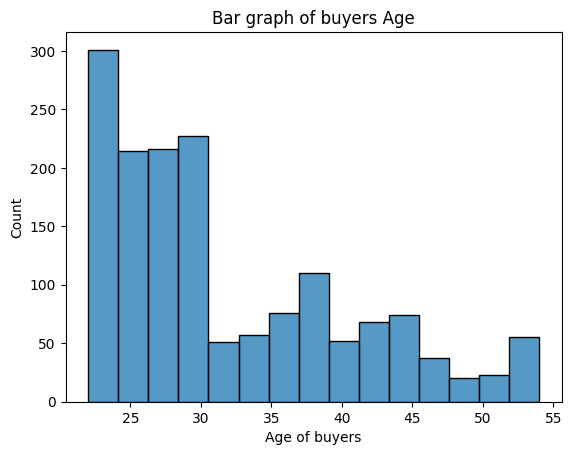

In [76]:
plt.xlabel('Age of buyers')
plt.title('Bar graph of buyers Age')
sns.histplot(data=df, x='Age')
plt.show()



*   Majority of the buyers are below 30 years in age.



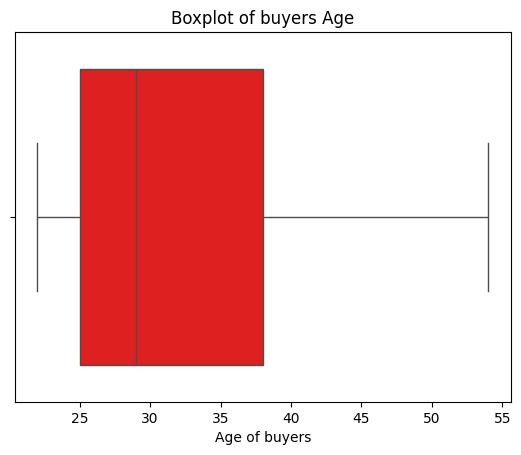

In [77]:
plt.xlabel('Age of buyers')
plt.title('Boxplot of buyers Age')
sns.boxplot(data=df, x='Age', color='red')
plt.show()



*   Its slightly right skewed graph.
*   50% of buyers age lie between 25 to 38 years.






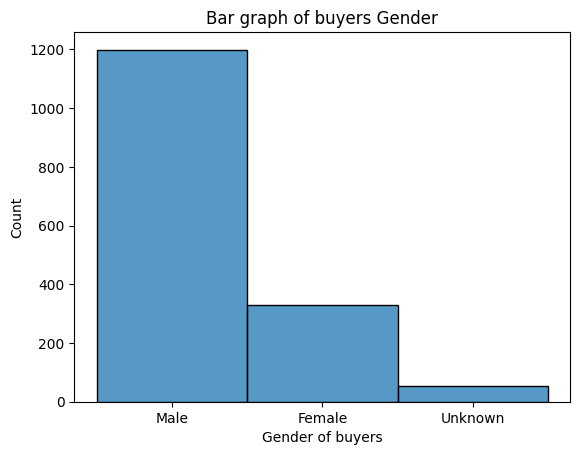

In [78]:
plt.xlabel('Gender of buyers')
plt.title('Bar graph of buyers Gender')
sns.histplot(data=df, x='Gender')
plt.show()



*   As graph shows most of the buyers are male followed by female.



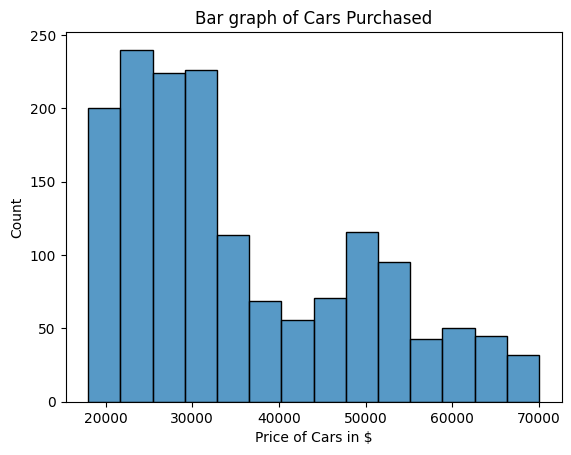

In [80]:
plt.xlabel('Price of Cars in $')
plt.title('Bar graph of Cars Purchased')
sns.histplot(data=df, x='Price')
plt.show()



*   Majority of car prices ranges between 20000 to 30000 dollors




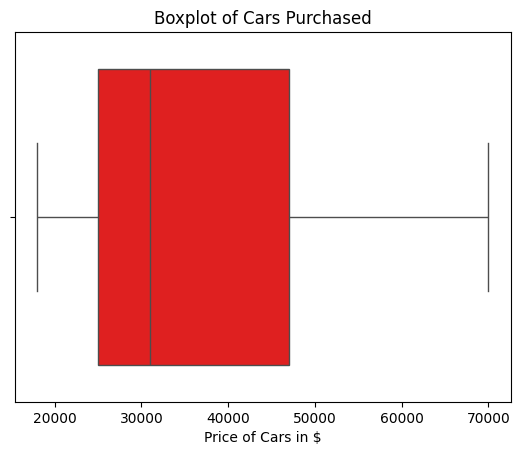

In [81]:
plt.xlabel('Price of Cars in $')
plt.title('Boxplot of Cars Purchased')
sns.boxplot(data=df, x='Price', color='red')
plt.show()



*   Its right skewed graph representation.
*   50% of cars price ranges between 25000 to 48000 dollors.
*   Highest price of car is around 70000 dollors.





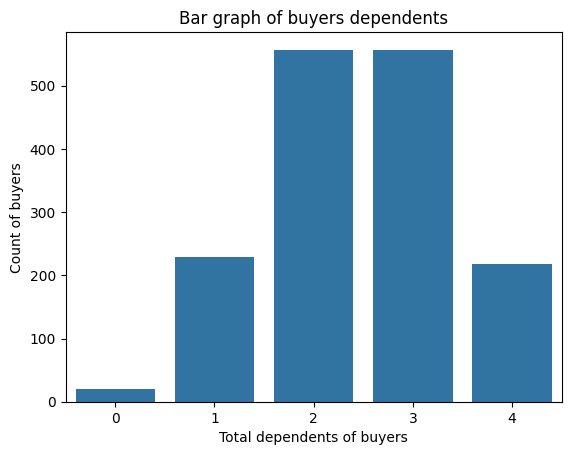

In [106]:
plt.title('Bar graph of buyers dependents')
plt.xlabel('Total dependents of buyers')
plt.ylabel('Count of buyers')
sns.countplot(data=df, x='No_of_Dependents')
plt.show()



*   Majority of dependents are 2 - 3 followed by 1 - 4.




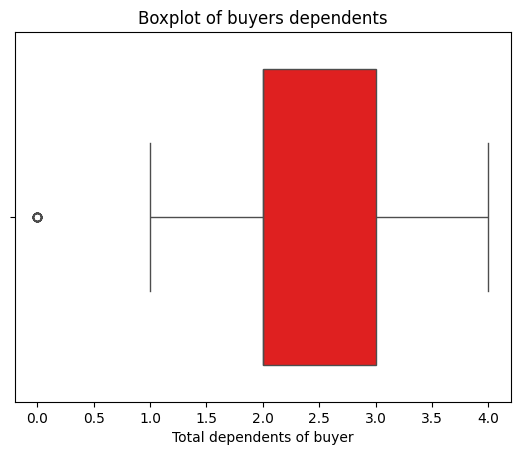

In [83]:
plt.xlabel('Total dependents of buyer')
plt.title('Boxplot of buyers dependents')
sns.boxplot(data=df, x='No_of_Dependents', color='red')
plt.show()



*   Boxplot shows Mojority of buyers dependent are 2-3
*   Maximum reaches to 4
*   While some having NO or 0 dependents shows as outliers





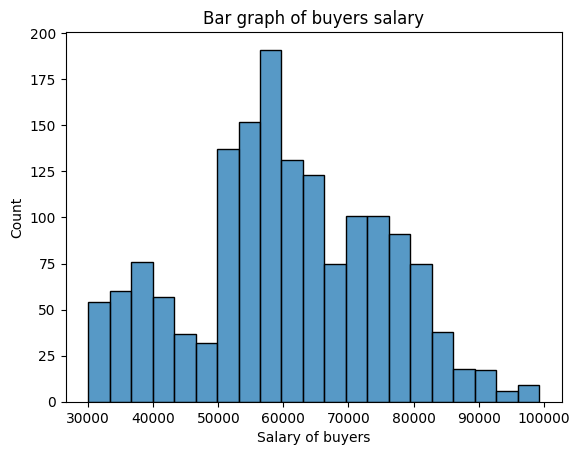

In [84]:
plt.xlabel('Salary of buyers')
plt.title('Bar graph of buyers salary')
sns.histplot(data=df, x='Salary')
plt.show()



*   Graph seems to be normally distributed




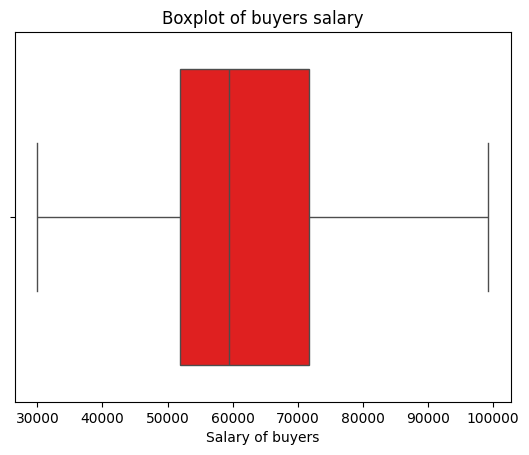

In [85]:
plt.xlabel('Salary of buyers')
plt.title('Boxplot of buyers salary')
sns.boxplot(data=df, x='Salary', color='red')
plt.show()



*   Boxplot shows 50% of buyers salary ranges between 52000 to 72000 dollors.




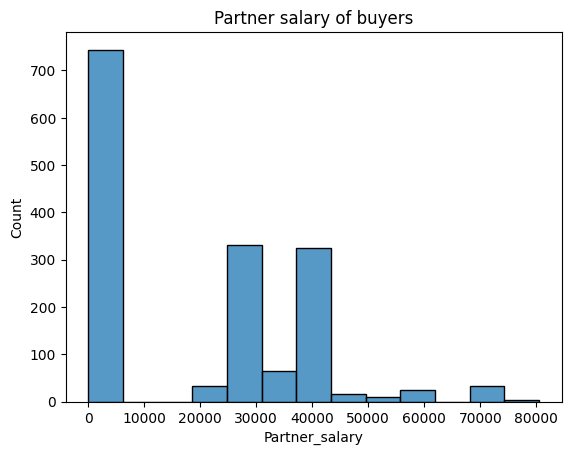

In [91]:
plt.title('Partner salary of buyers')
sns.histplot(data=df, x='Partner_salary')
plt.show()

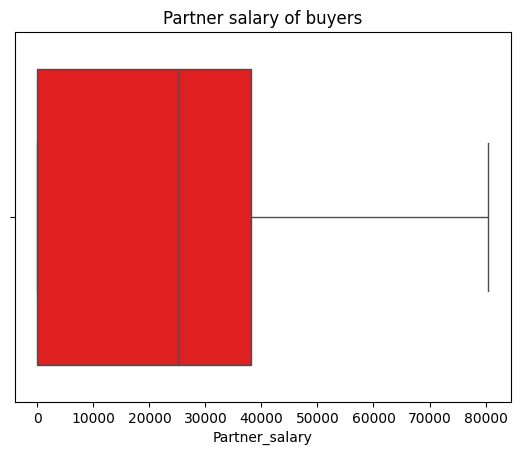

In [89]:
plt.title('Partner salary of buyers')
sns.boxplot(data=df, x='Partner_salary', color='red')
plt.show()



*   Boxplot shows Partner salary is right skewed representation




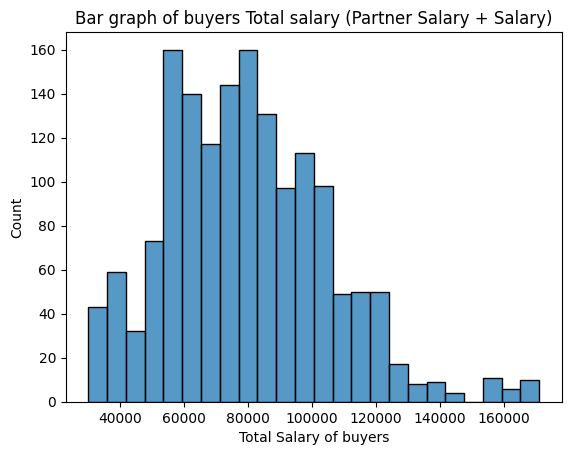

In [93]:
plt.xlabel('Total Salary of buyers')
plt.title('Bar graph of buyers Total salary (Partner Salary + Salary)')
sns.histplot(data=df, x='Total_salary')
plt.show()

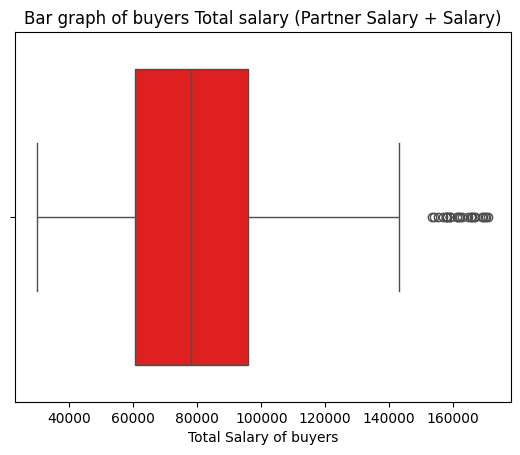

In [94]:
plt.xlabel('Total Salary of buyers')
plt.title('Bar graph of buyers Total salary (Partner Salary + Salary)')
sns.boxplot(data=df, x='Total_salary', color='red')
plt.show()



*   Total Salary distribution is highly Right skewed.
*   Also having outliers present due to extremely higher total salary.
*   Total Salary = Salary + Partner Salary






### Categorical Variables

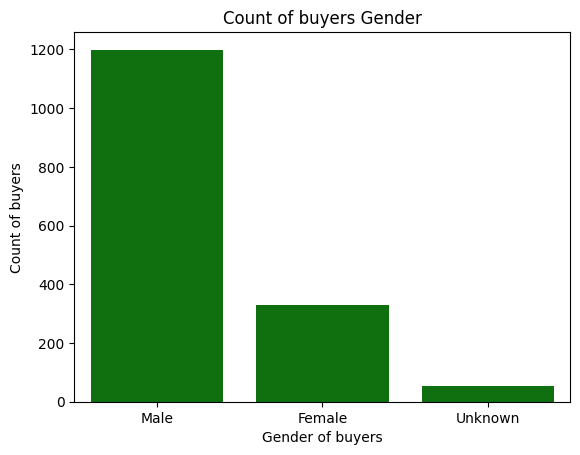

In [107]:
plt.title('Count of buyers Gender')
plt.xlabel('Gender of buyers')
plt.ylabel('Count of buyers')
sns.countplot(data=df, x='Gender', color='green')
plt.show()



*   There are 1199 Males, 329 Females and 53 unknowns.



In [103]:
#actual number of buyer's gender
df['Gender'].value_counts()

,count
Gender,
Male,1199
Female,329
Unknown,53


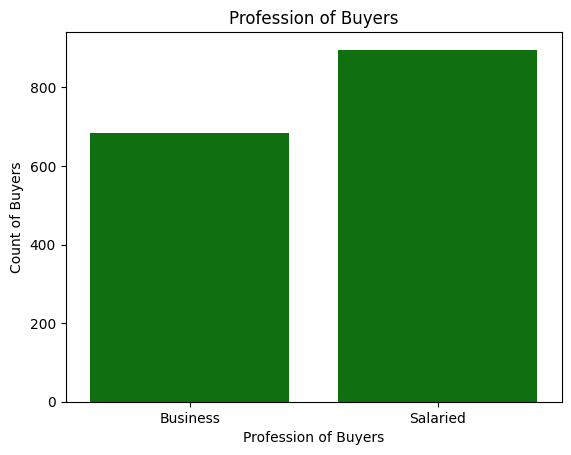

In [104]:
plt.title('Profession of Buyers')
plt.ylabel('Count of Buyers')
plt.xlabel('Profession of Buyers')
sns.countplot(data=df, x='Profession', color='green')
plt.show()



*   Majority of buyers are salaried as compare to business profession.



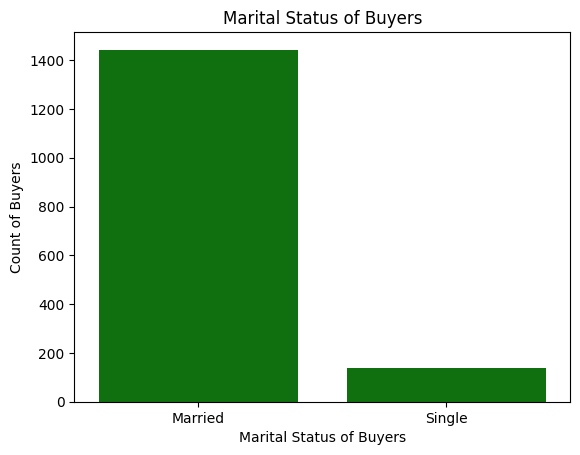

In [108]:
plt.title('Marital Status of Buyers')
plt.ylabel('Count of Buyers')
plt.xlabel('Marital Status of Buyers')
sns.countplot(data=df, x='Marital_status', color='green')
plt.show()



*   Around 90% of buyers are Married.



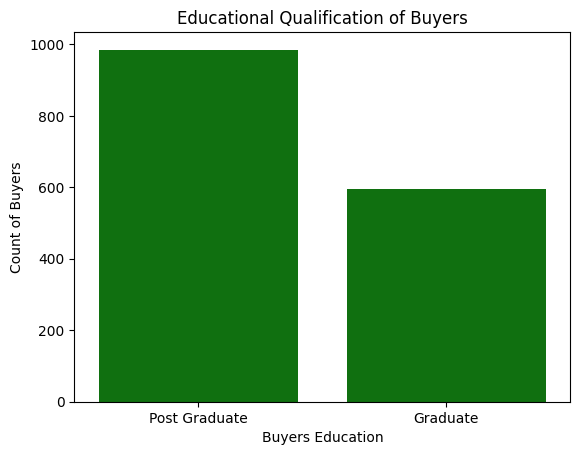

In [113]:
plt.title('Educational Qualification of Buyers')
plt.ylabel('Count of Buyers')
plt.xlabel('Buyers Education')
sns.countplot(data=df, x='Education', color='green')
plt.show()



*   More buyers are Post Graduate in education.



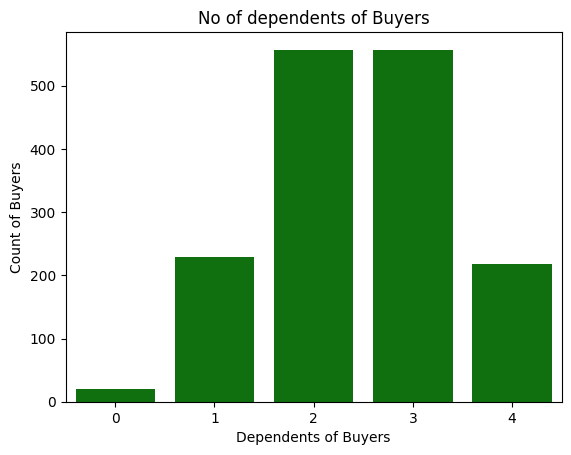

In [111]:
plt.title('No of dependents of Buyers')
plt.ylabel('Count of Buyers')
plt.xlabel('Dependents of Buyers')
sns.countplot(data=df, x='No_of_Dependents', color='green')
plt.show()



*   Majority of dependents are 2-3 in numbers.



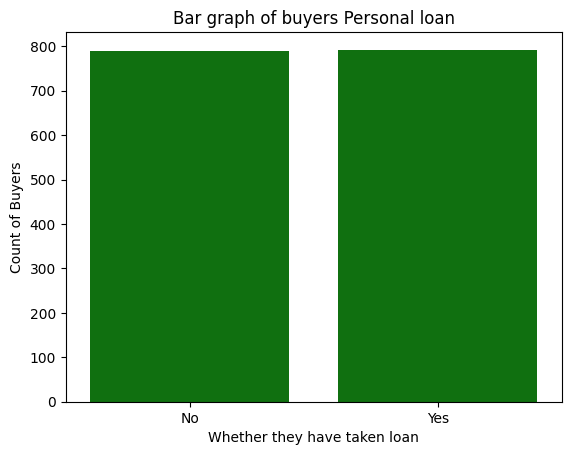

In [115]:
plt.title('Bar graph of buyers Personal loan')
plt.ylabel('Count of Buyers')
plt.xlabel('Whether they have taken loan')
sns.countplot(data=df, x='Personal_loan', color='green')
plt.show()



*   Personal Loan are equally split as buyers taken loan is equal to buyers who haven't taken loan.



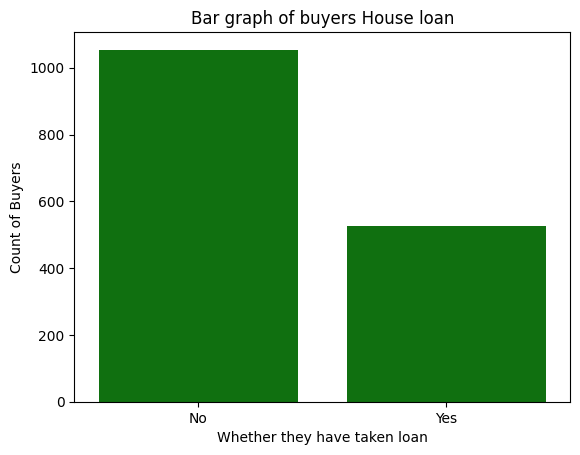

In [114]:
plt.title('Bar graph of buyers House loan')
plt.ylabel('Count of Buyers')
plt.xlabel('Whether they have taken loan')
sns.countplot(data=df, x='House_loan', color='green')
plt.show()



*   Most of the people haven't taken House loan.



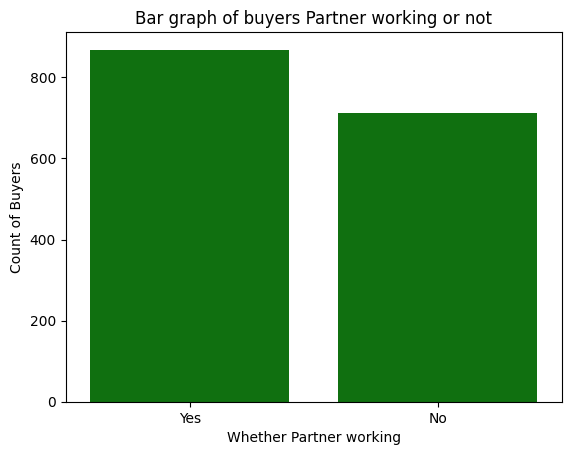

In [118]:
plt.title('Bar graph of buyers Partner working or not')
plt.ylabel('Count of Buyers')
plt.xlabel('Whether Partner working')
sns.countplot(data=df, x='Partner_working', color='green')
plt.show()



*   Partner working are around 850 while not working are around 700, So its having very slight difference.



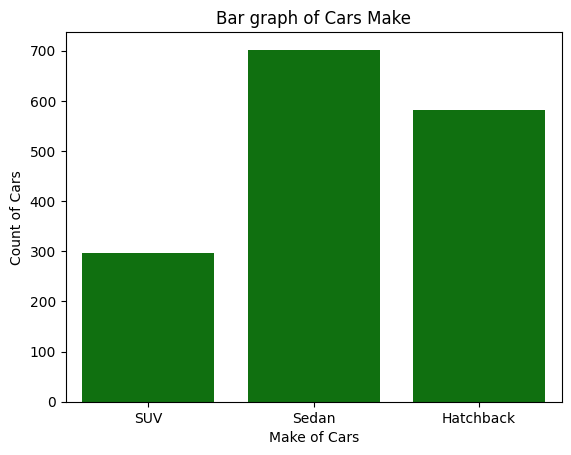

In [105]:
plt.title('Bar graph of Cars Make')
plt.xlabel('Make of Cars')
plt.ylabel('Count of Cars')
sns.countplot(data=df, x='Make', color='green')
plt.show()



*   Sedan is the make preferred among buyers followed by Hatchback and SUV.



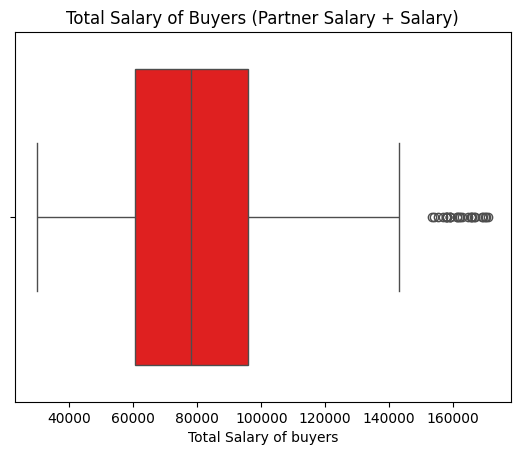

In [131]:
plt.title('Total Salary of Buyers (Partner Salary + Salary)')
plt.xlabel('Total Salary of buyers')
sns.boxplot(data=df, x='Total_salary', color='red')
plt.show();



*   In Total Salary, we have outliers present if needed we can treat them with IQR method.



In [15]:
Q1 = df['Total_salary'].quantile(0.25)
Q3 = df['Total_salary'].quantile(0.75)
IQR = Q3 - Q1
out = df[(df['Total_salary'] > Q1 - 1.5*IQR) & (df['Total_salary'] < Q3 + 1.5*IQR)]
#We have treated outliers with IQR method
#I have taken above treatment in 'out' DataFrame so that it doesn't effect actual DataFrame 'df'

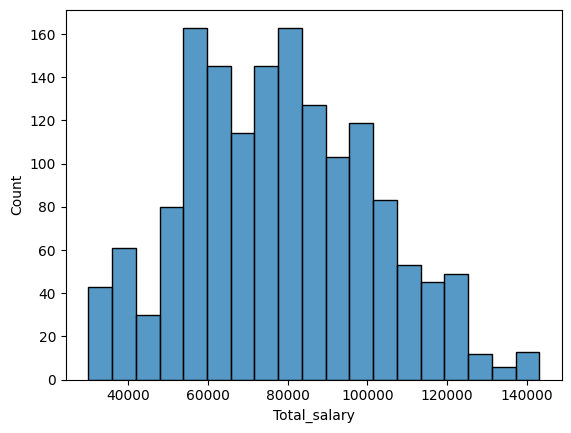

In [16]:
sns.histplot(data=out, x='Total_salary');

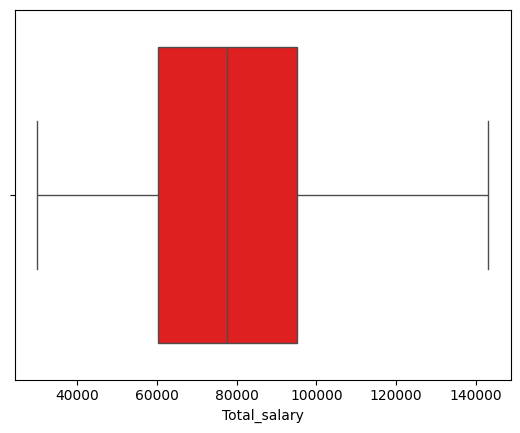

In [17]:
sns.boxplot(data=out, x='Total_salary', color='red')
plt.show()



*   Now after treating outliers we can see boxplot like this with no outliers, almost normally distributed.


### Observation and Insights



*   Most number of buyers are salaried shows stable income source that leads to purchase of vehicles.
*   Most of the young age buyers prefer mid-range cars as align with salary.
*   Small number of customers prefer high-range cars.





## Bivariate Analysis

### Between all numerical values





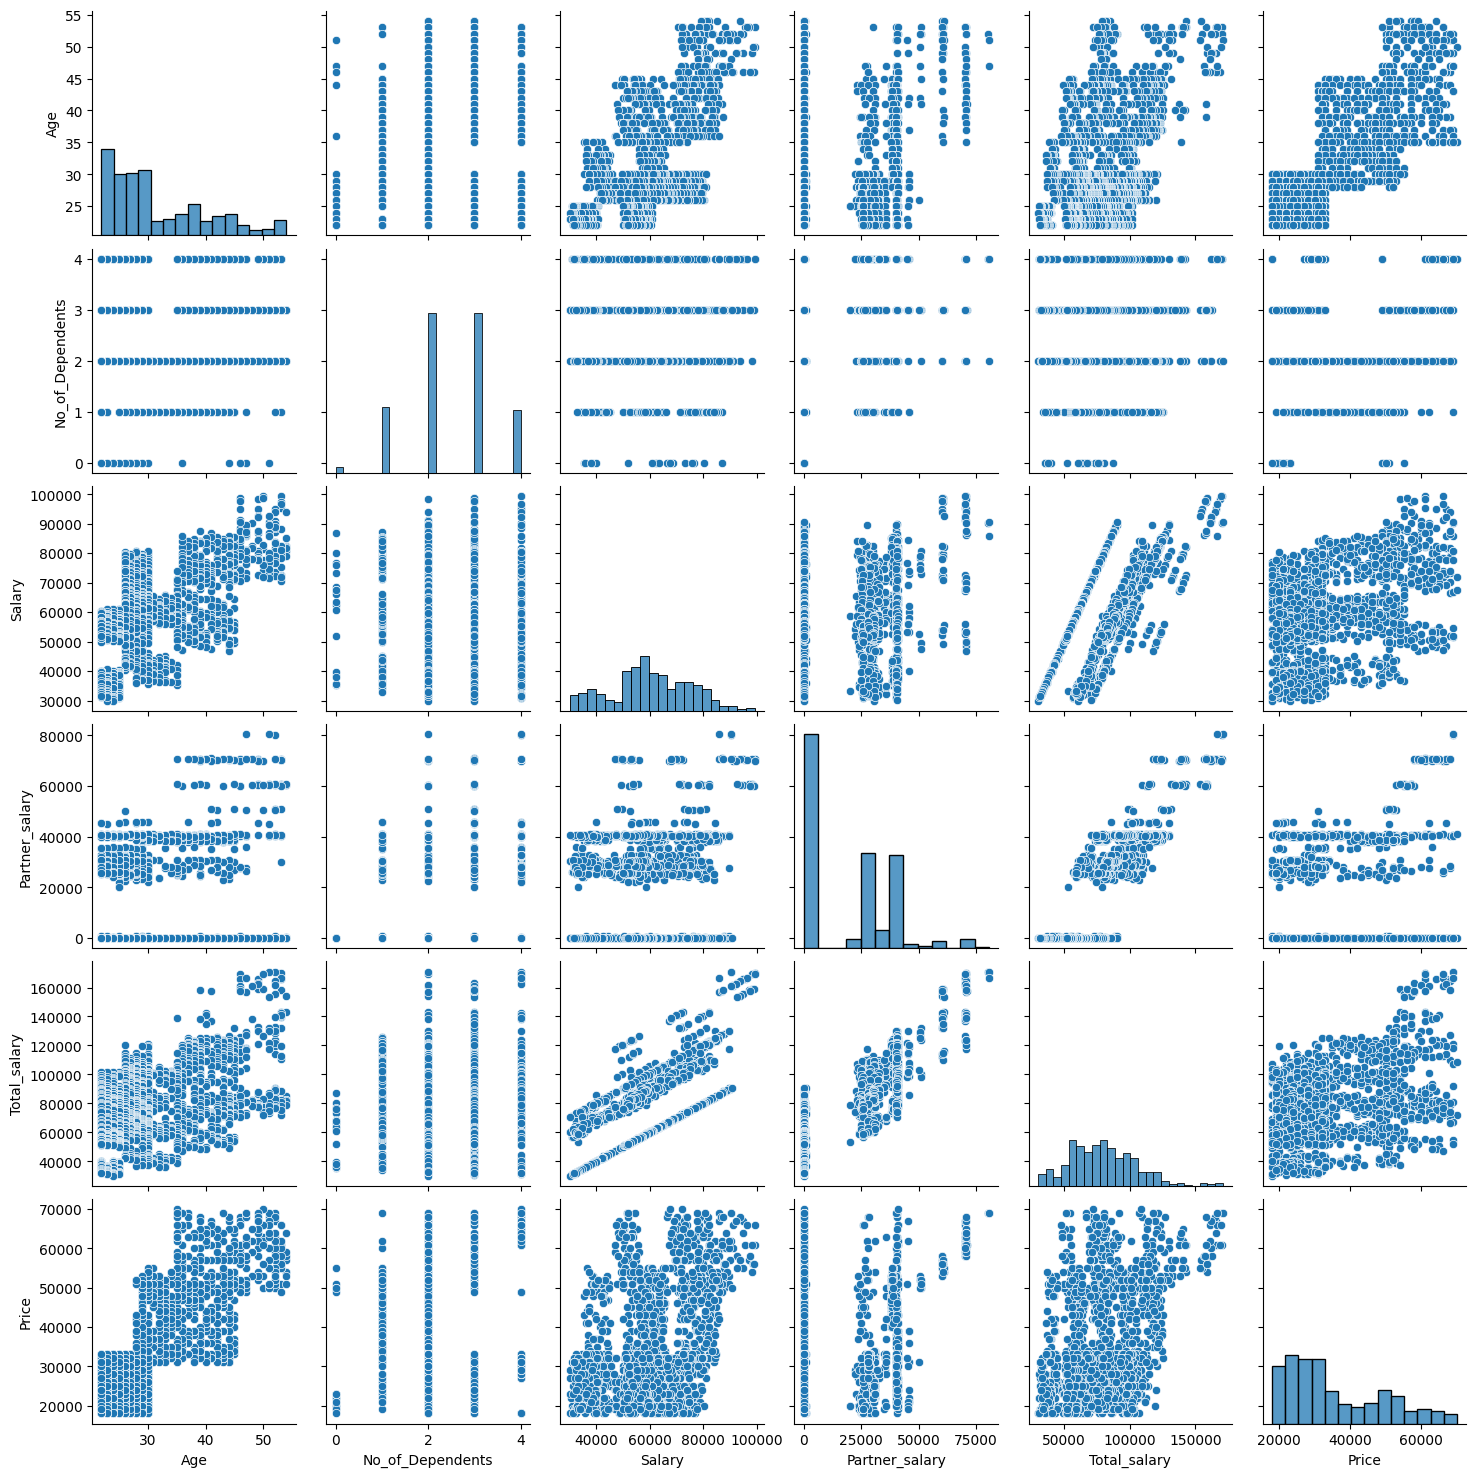

In [18]:
sns.pairplot(data=df, vars=['Age', 'No_of_Dependents', 'Salary', 'Partner_salary', 'Total_salary', 'Price'])
plt.show()
#to show relationship between numerical values



*   Above Pairplot shows relationship between all numerical values.



In [43]:
col=['Age', 'No_of_Dependents', 'Salary', 'Partner_salary', 'Total_salary', 'Price']
df[col] = df[col].apply(pd.to_numeric, errors='coerce')

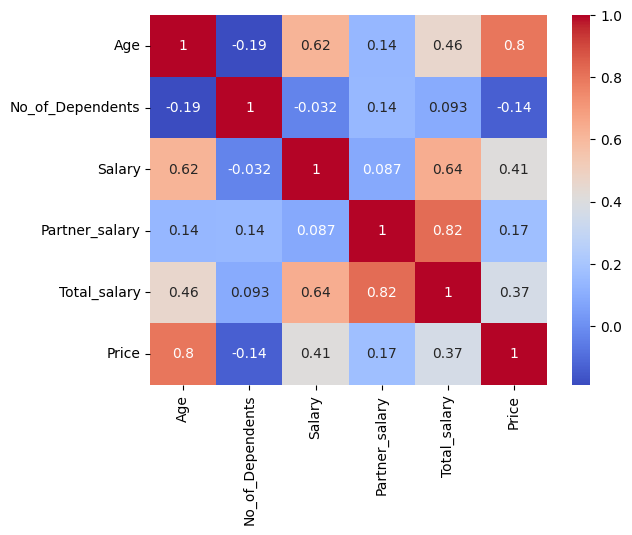

In [44]:
sns.heatmap(df[col].corr(), annot=True, cmap='coolwarm')
plt.show()
#to show correlation



*   Above Heatmap shows correlation between all numerical values



### Between Numerical and Categorical Variables

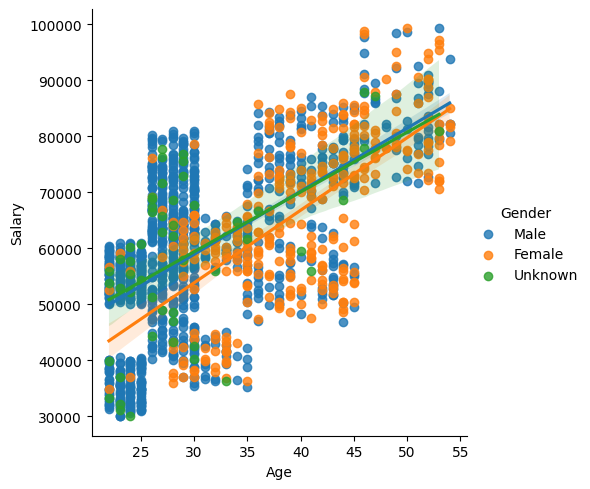

In [45]:
sns.lmplot(data = df, x = 'Age', y = 'Salary', hue='Gender')
plt.show()



*   Graph shows strong positive relation between age and salary, trend goes upward from left to right.

*   Means when customer age is going higher their salary increases.





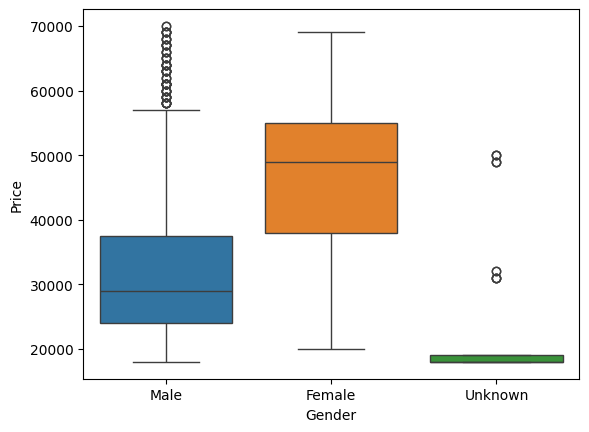

In [46]:
sns.boxplot(x='Gender', y='Price', data=df, legend=False, hue='Gender');

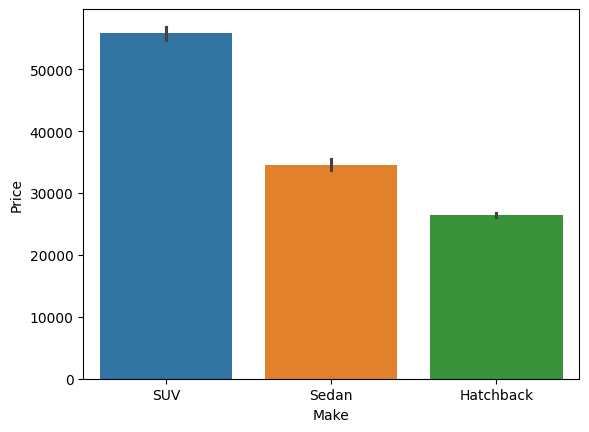

In [47]:
sns.barplot(x='Make', y='Price', data=df, legend=False, hue='Make');

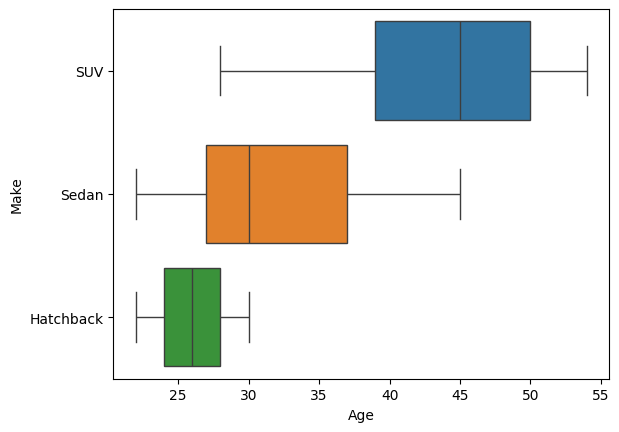

In [48]:
sns.boxplot(x='Age', y='Make', data=df, legend=False, hue='Make');

## Key Questions


1.   Do men tend to prefer SUVs more compared to women?






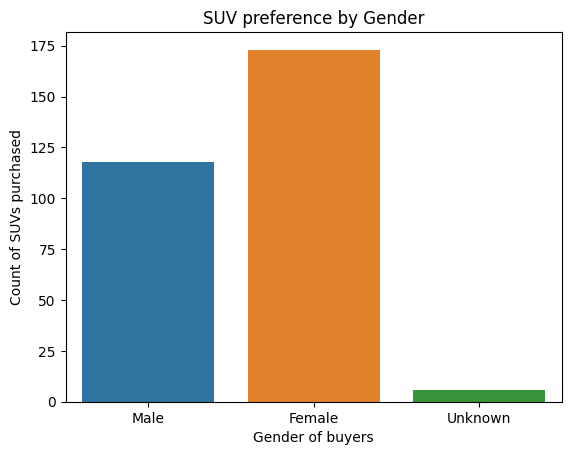

In [163]:
plt.title('SUV preference by Gender')
plt.ylabel('Count of SUVs purchased')
plt.xlabel('Gender of buyers')
suvs = df[df['Make'] == 'SUV']
sns.countplot(data=suvs, x='Gender', hue='Gender', legend=False)
plt.show()




2.   What is the likelihood of a salaried person buying a Sedan?



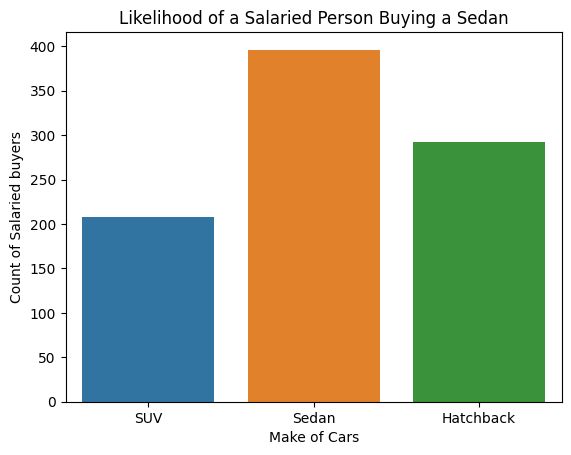

In [164]:
plt.title('Likelihood of a Salaried Person Buying a Sedan')
plt.xlabel('Make of Cars')
plt.ylabel('Count of Salaried buyers')
total_sal=df[(df['Profession'] == 'Salaried')]
sns.countplot(data=total_sal, x='Make', hue='Make', legend=False);



3.   What evidence or data supports Sheldon Cooper's claim that a salaried male is an easier target for a SUV sale over a Sedan sale?



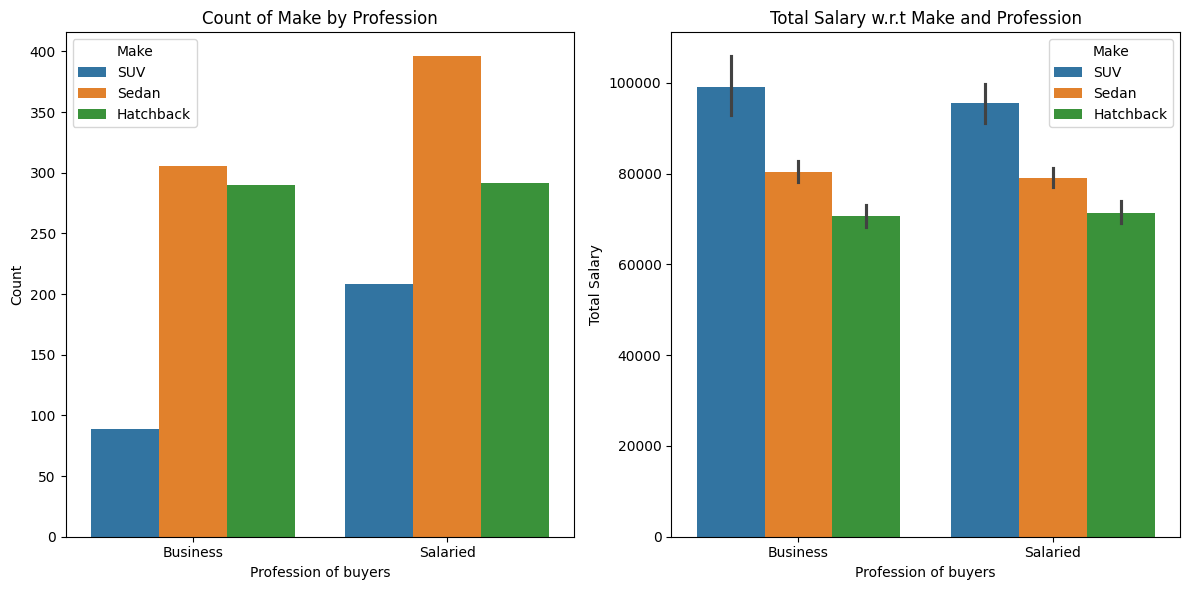

In [174]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
sns.countplot(data=df, x='Profession', hue='Make', ax=axes[0], legend=True)
axes[0].set_title('Count of Make by Profession')
axes[0].set_xlabel('Profession of buyers')
axes[0].set_ylabel('Count')

sns.barplot(data=df, x='Profession', y='Total_salary', hue='Make', ax=axes[1], legend=True)
axes[1].set_title('Total Salary w.r.t Make and Profession')
axes[1].set_xlabel('Profession of buyers')
axes[1].set_ylabel('Total Salary')

plt.tight_layout()
plt.show()



4.   How does the the amount spent on purchasing automobiles vary by gender?



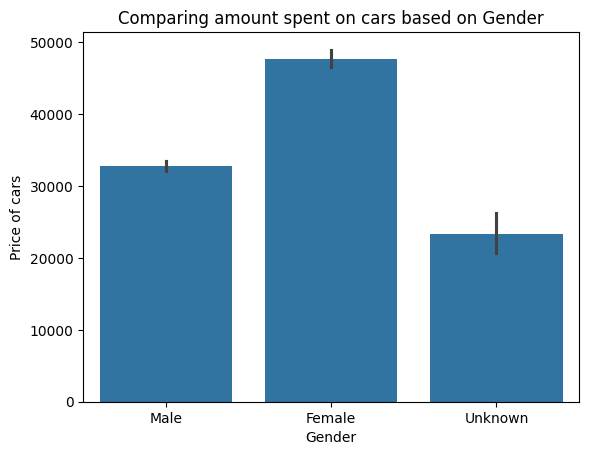

In [177]:
plt.ylabel('Price of cars')
plt.xlabel('Gender')
plt.title('Comparing amount spent on cars based on Gender')
sns.barplot(data=df, x='Gender', y='Price')
plt.show()



5.   How much money was spent on purchasing automobiles by individuals who took a personal loan?



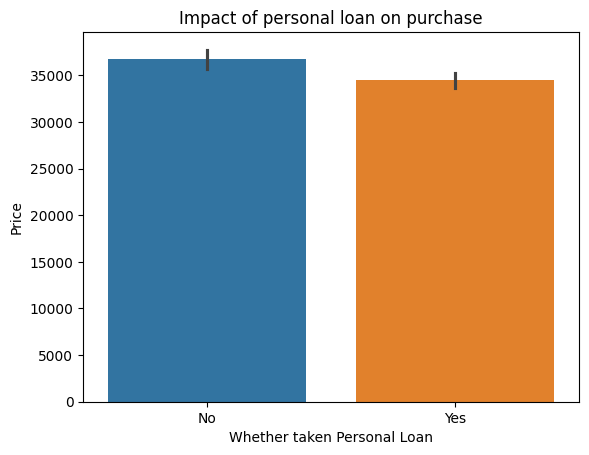

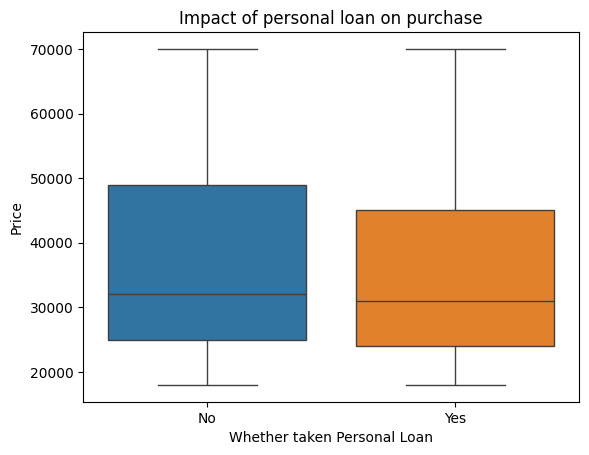

In [186]:
plt.xlabel("Whether taken Personal Loan")
plt.ylabel("Price")
plt.title("Impact of personal loan on purchase")
sns.barplot(data=df, x='Personal_loan',y='Price', hue='Personal_loan', legend=False )

plt.show();

plt.xlabel("Whether taken Personal Loan")
plt.ylabel("Price")
plt.title("Impact of personal loan on purchase")
sns.boxplot(data=df, x='Personal_loan',y='Price', hue='Personal_loan', legend=False )

plt.show();



6.   How does having a working partner influence the purchase of higher-priced cars?



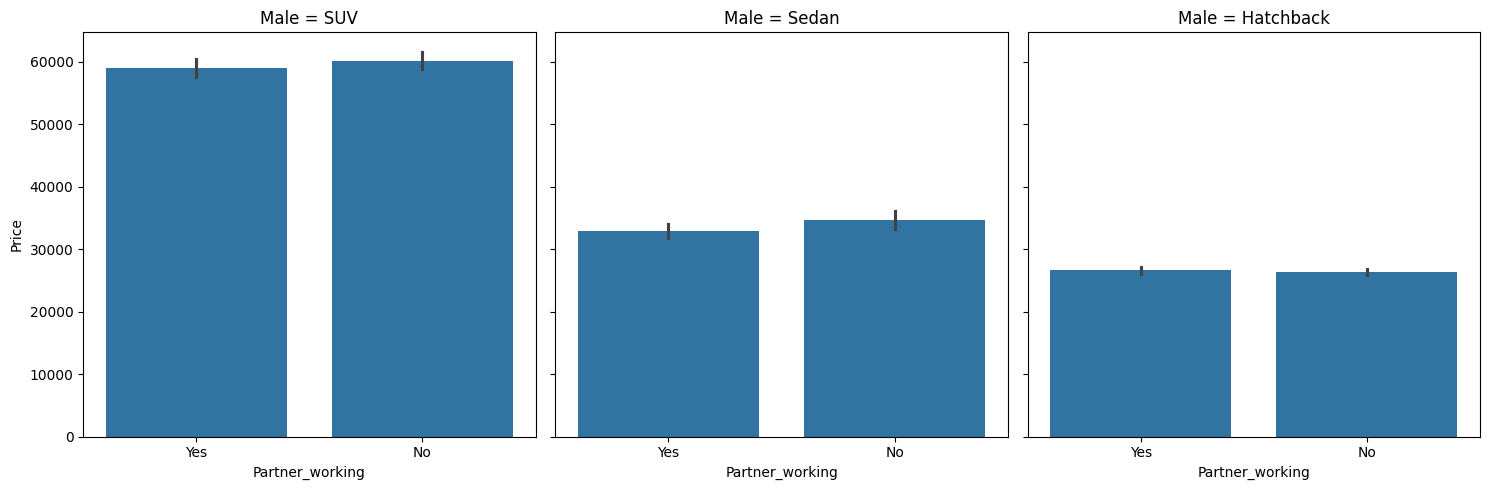

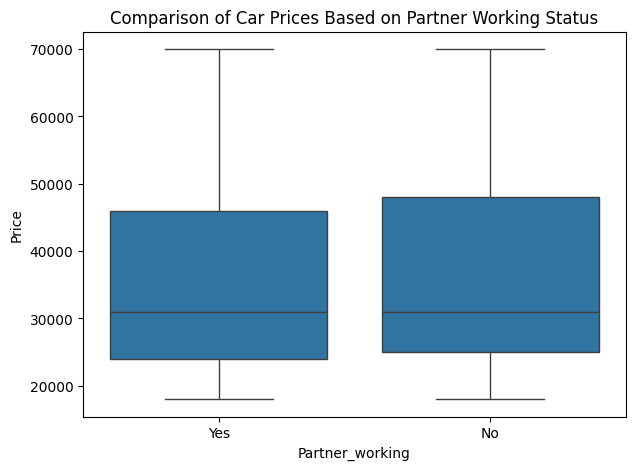

In [189]:

# Create subplots for different car types (Make)
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

# Loop over each car type
car_types = ['SUV', 'Sedan', 'Hatchback']

for i, car in enumerate(car_types):
 subset = df[(df['Gender'] == 'Male') & (df['Make'] == car)]
 sns.barplot(data=subset, x='Partner_working', y='Price', ax=axes[i])
 axes[i].set_title(f'Male = {car}')
 axes[i].set_xlabel('Partner_working')
 axes[i].set_ylabel('Price' if i == 0 else '')

plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x='Partner_working', y='Price')
plt.title('Comparison of Car Prices Based on Partner Working Status')
plt.xlabel('Partner_working')
plt.ylabel('Price')
plt.show()

## Actionable Insights & Recommendations

###  Actionable Insights



1.  **Ineffective "One-Size-Fits-All" Strategy**

    Austo Motors' current marketing and sales approach is too generalized. It fails to resonate deeply because the customer base is not monolithic but composed of distinct segments—families, professionals, and young buyers—each driven by different needs and aspirations.

2.  **Regional Demographics Drive Product Success**

    There is a clear correlation between local demographics and sales performance. Dealerships in suburban, family-oriented areas see high demand for SUVs, while those in urban centers with younger populations sell more hatchbacks. This indicates that inventory and marketing require a localized approach.

3.  **SUVs: The Engine of Growth Fueled by Financing**

    The SUV segment is the primary revenue driver, particularly popular among family-focused consumers. A crucial factor enabling these sales is the widespread use of personal loans, making accessible and attractive financing a critical component of the buyer's journey.

4.  **Hatchbacks: A Market Governed by Practicality and Price**

    For the hatchback segment, purchasing decisions are overwhelmingly practical. Buyers are highly sensitive to price, prioritizing fuel economy, low maintenance, and overall affordability over performance or premium features.



### Business Recommendations



1.  **Adopt a Segment-Centric Go-to-Market Strategy**

    Transform the sales and marketing functions to align with customer profiles.
    * **Targeted Messaging:** Develop distinct campaigns for each vehicle type. Market SUVs with themes of safety and family; Sedans with sophistication and technology; and Hatchbacks with fun and economy.
    * **Empower Sales Teams:** Train staff to quickly identify customer segments and tailor their sales pitch and vehicle recommendations to match the buyer's specific motivations.

2.  **Optimize Inventory and Supply Chain for Local Markets**

    Shift from a uniform inventory strategy to a data-driven, localized model.
    * **Suburban Dealerships:** Increase stock of SUVs and family-oriented vehicles.
    * **Urban & Youth-Heavy Areas:** Prioritize stocking a higher volume of hatchbacks and entry-level models.

3.  **Build a Strategic Financial Partnership Program**

    Acknowledge the importance of financing and use it as a competitive advantage.
    * **Collaborate with Lenders:** Form partnerships with banks to create exclusive, low-interest loan packages, especially for the popular SUV models.
    * **Promote Financing Options:** Integrate these financial solutions directly into marketing efforts to make the purchase proposition more attainable and appealing.

4.  **Steer Product Innovation with Market Intelligence**

    Use these insights to guide future planning and development.
    * **Expand the SUV Portfolio:** Capitalize on strong demand by developing a wider range of SUV models at different sizes and price points.
    * **Maintain Hatchback Competitiveness:** Ensure the hatchback lineup continues to lead on value by focusing on excellent mileage, affordability, and low ownership costs.